# PHQ-8 Depression Detection — HuBERT + Bidirectional LSTM (Regression)

**Architecture**: Frozen HuBERT (`facebook/hubert-base-ls960`) → sequence of mean-pooled 768-dim segment features → `BiLSTM` → mean-pool over time → `Dropout` → `Linear(2·hidden, 1)`.

**Approach**: HuBERT weights are frozen. The cached features from `HuBERT_linear` are reused directly — no re-extraction needed. The biLSTM sees each participant's segments **as an ordered sequence**, capturing temporal context across the interview. One PHQ-8 prediction is made per participant.

**Input**: Ordered sequence of 768-dim HuBERT features, one per 8-second window (4-second hop).

**Target**: PHQ-8 score (continuous, 0–24).

## 1. Install Dependencies

In [1]:
!pip install transformers librosa tqdm pandas numpy scipy --quiet
print("All packages ready.")

All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from tqdm import tqdm

print("Imports successful.")

Imports successful.


In [3]:
# --- Paths ---
BASE_DIR      = Path("..")
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV      = PROCESSED_DIR / "segment_metadata.csv"

FEATURE_CACHE = PROCESSED_DIR / "hubert_features.npz"   # shared with HuBERT_linear

SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "hubert_bilstm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device   : {DEVICE}")
print(f"Feature cache  : {FEATURE_CACHE.resolve()}")
print(f"Checkpoint dir : {SAVE_DIR.resolve()}")

Using device   : cuda
Feature cache  : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\processed\hubert_features.npz
Checkpoint dir : C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\hubert_bilstm


## 3. Load Segment Metadata

Used only to read the train/dev/test split and PHQ-8 labels per participant.

In [4]:
meta = pd.read_csv(META_CSV)

participant_info = (
    meta.groupby("participant_id")
    .first()[["split", "phq_score"]]
    .reset_index()
)

print(f"Total segments    : {len(meta):,}")
print(f"Total participants: {len(participant_info)}")
print("\nSplit breakdown:")
for split, grp in participant_info.groupby("split"):
    display_name = "validation" if split == "dev" else split
    print(f"  {display_name:10s}: {len(grp):3d} participants")
print(f"\nPHQ-8 range: {meta['phq_score'].min():.0f} \u2013 {meta['phq_score'].max():.0f}")

Total segments    : 21,588
Total participants: 189

Split breakdown:
  validation:  35 participants
  test      :  47 participants
  train     : 107 participants

PHQ-8 range: 0 – 23


## 4. Load HuBERT Features

Loads the cached `.npz` produced by `HuBERT_linear.ipynb`.
Features are grouped by participant and kept **in order** (segment index preserved)
so the biLSTM sees the interview as a temporal sequence.

In [5]:
if not FEATURE_CACHE.exists():
    raise FileNotFoundError(
        f"Feature cache not found at {FEATURE_CACHE}.\n"
        "Please run HuBERT_linear.ipynb first to extract and cache the features."
    )

print(f"Loading features from {FEATURE_CACHE.name} ...")
cache         = np.load(FEATURE_CACHE, allow_pickle=False)
all_feats_np  = cache["feats"]       # (N, 768)
all_scores_np = cache["phq_scores"]  # (N,)
all_pids_np   = cache["pids"]        # (N,)
all_splits_np = cache["splits"]      # (N,) bytes

# Group by participant, preserving segment order (cache is stored in order)
# in_memory[split][pid] = {"feats": [...], "label": score}
in_memory = {
    "train": defaultdict(lambda: {"feats": [], "label": None}),
    "dev":   defaultdict(lambda: {"feats": [], "label": None}),
    "test":  defaultdict(lambda: {"feats": [], "label": None}),
}

for feat, score, pid, split_b in zip(all_feats_np, all_scores_np,
                                      all_pids_np, all_splits_np):
    split = split_b.decode()
    pid   = int(pid)
    in_memory[split][pid]["feats"].append(feat)
    in_memory[split][pid]["label"] = float(score)

# Convert to plain lists of (pid, data) for iteration
splits_list = {
    s: list(in_memory[s].items()) for s in ("train", "dev", "test")
}

for s, name in [("train", "train"), ("dev", "validation"), ("test", "test")]:
    n_segs = sum(len(d["feats"]) for _, d in splits_list[s])
    print(f"  {name:10s}: {len(splits_list[s]):3d} participants, {n_segs:,} segments")

Loading features from hubert_features.npz ...
  train     : 107 participants, 11,362 segments
  validation:  35 participants, 4,322 segments
  test      :  47 participants, 5,904 segments


## 5. Training Configuration

In [6]:
# --- Model hyper-parameters ---
HUBERT_DIM             = 768
LSTM_HIDDEN_DIM        = 64   # per direction; output is 2*64 = 128
LSTM_NUM_LAYERS        = 2
DROPOUT                = 0.5

# --- Training hyper-parameters ---
PARTICIPANT_BATCH_SIZE  = 8    # participants per gradient update
NUM_EPOCHS              = 500
LEARNING_RATE           = 1e-4
WEIGHT_DECAY            = 1e-3
EARLY_STOPPING_PATIENCE = 50
CHECKPOINT_FREQ         = 10
GRAD_CLIP_NORM          = 1.0  # max gradient norm for LSTM stability

print("Training configuration set.")
print(f"  LSTM hidden dim        : {LSTM_HIDDEN_DIM} (x2 bidirectional = {2*LSTM_HIDDEN_DIM})")
print(f"  LSTM layers            : {LSTM_NUM_LAYERS}")
print(f"  Dropout                : {DROPOUT}")
print(f"  Participant batch size : {PARTICIPANT_BATCH_SIZE}")
print(f"  Epochs                 : {NUM_EPOCHS}")
print(f"  Learning rate          : {LEARNING_RATE}")
print(f"  Weight decay           : {WEIGHT_DECAY}")
print(f"  Early stopping         : {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Grad clip norm         : {GRAD_CLIP_NORM}")

Training configuration set.
  LSTM hidden dim        : 64 (x2 bidirectional = 128)
  LSTM layers            : 2
  Dropout                : 0.5
  Participant batch size : 8
  Epochs                 : 500
  Learning rate          : 0.0001
  Weight decay           : 0.001
  Early stopping         : 50 epochs
  Grad clip norm         : 1.0


## 6. Model — HuBERT BiLSTM Regressor

In [7]:
class HuBERTBiLSTM(nn.Module):
    """
    Bidirectional LSTM regressor on top of frozen HuBERT features.

    Input  : (T, 768)  — ordered sequence of segment features for one participant
    Output : scalar    — predicted PHQ-8 score

    Processing:
        (T, 768)
        → unsqueeze(0) → (1, T, 768)
        → BiLSTM       → (1, T, 2*hidden_dim)
        → mean over T  → (1, 2*hidden_dim)
        → Dropout + Linear(2*hidden_dim, 1)
        → scalar
    """
    def __init__(self,
                 input_dim:  int   = HUBERT_DIM,
                 hidden_dim: int   = LSTM_HIDDEN_DIM,
                 num_layers: int   = LSTM_NUM_LAYERS,
                 dropout:    float = DROPOUT):
        super(HuBERTBiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size   = input_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * hidden_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (T, 768)
        x   = x.unsqueeze(0)           # (1, T, 768)
        out, _ = self.lstm(x)          # (1, T, 2*hidden_dim)
        pooled = out.mean(dim=1)       # (1, 2*hidden_dim)  — mean-pool over time
        return self.head(pooled).squeeze()   # scalar


model = HuBERTBiLSTM().to(DEVICE)

# Sanity check
with torch.no_grad():
    dummy = torch.zeros(10, HUBERT_DIM, device=DEVICE)   # 10 segments
    out   = model(dummy)
    print(f"Output shape (10 segments): {out.shape}  (expected: torch.Size([]))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape (10 segments): torch.Size([])  (expected: torch.Size([]))
Trainable parameters: 526,465


## 7. Training Loop

In [8]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss     = float("inf")
epochs_no_improve = 0

train_participants = splits_list["train"]
print(f"Training on {len(train_participants)} participants.")


def train_epoch():
    """
    Participant-level training pass.
    Each participant's segments are fed as an ordered sequence to the biLSTM.
    One prediction per participant, MSE against participant label.
    Gradients accumulated over PARTICIPANT_BATCH_SIZE participants per update.
    """
    model.train()
    idx     = torch.randperm(len(train_participants)).tolist()
    batches = [idx[i : i + PARTICIPANT_BATCH_SIZE]
               for i in range(0, len(idx), PARTICIPANT_BATCH_SIZE)]

    total_loss, n = 0.0, 0

    for batch in batches:
        optimizer.zero_grad()
        batch_size = len(batch)

        for i in batch:
            _, data = train_participants[i]
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )                                                   # (T, 768)
            label = torch.tensor(
                data["label"], dtype=torch.float32, device=DEVICE
            )                                                   # scalar

            pred = model(feats)                                 # scalar
            loss = criterion(pred, label) / batch_size
            loss.backward()

            total_loss += loss.item() * batch_size
            n          += 1

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

    return total_loss / n


def evaluate(split: str):
    """
    Participant-level evaluation.
    Each participant's segments are fed as a sequence; one prediction is made.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for pid, data in splits_list[split]:
            feats = torch.tensor(
                np.array(data["feats"]), dtype=torch.float32, device=DEVICE
            )
            pred  = model(feats).item()
            records.append((pid, pred, data["label"]))

    df   = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    mse  = float(np.mean((df["pred"].values - df["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, df


for epoch in range(1, NUM_EPOCHS + 1):

    train_mse            = train_epoch()
    val_mse, val_rmse, _ = evaluate("dev")

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch:3d}/{NUM_EPOCHS}]  "
          f"Train MSE: {train_mse:.4f}  "
          f"Val MSE: {val_mse:.4f}  "
          f"Val RMSE: {val_rmse:.4f}")

    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_HuBERT_biLSTM.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved → {ckpt_path.name}")

    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "HuBERT_biLSTM_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved → {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for "
                  f"{EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best validation MSE  : {best_val_loss:.4f}")
print(f"Best validation RMSE : {best_val_loss ** 0.5:.4f}  PHQ-8 points")

Training on 107 participants.
Epoch [  1/500]  Train MSE: 69.3763  Val MSE: 94.1368  Val RMSE: 9.7024
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 94.1368)
Epoch [  2/500]  Train MSE: 67.1660  Val MSE: 91.2974  Val RMSE: 9.5550
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 91.2974)
Epoch [  3/500]  Train MSE: 64.7863  Val MSE: 87.4631  Val RMSE: 9.3522
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 87.4631)
Epoch [  4/500]  Train MSE: 60.9704  Val MSE: 82.1484  Val RMSE: 9.0636
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 82.1484)
Epoch [  5/500]  Train MSE: 56.3815  Val MSE: 75.4241  Val RMSE: 8.6847
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 75.4241)
Epoch [  6/500]  Train MSE: 50.8888  Val MSE: 68.2374  Val RMSE: 8.2606
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 68.2374)
Epoch [  7/500]  Train MSE: 45.2568  Val MSE: 61.4474  Val RMSE: 7.8388
  Best model saved → HuBERT_biLSTM_best.pth  (val MSE 61.4474)
Epoch [  8/500]  Train MS

## 8. Training Curves

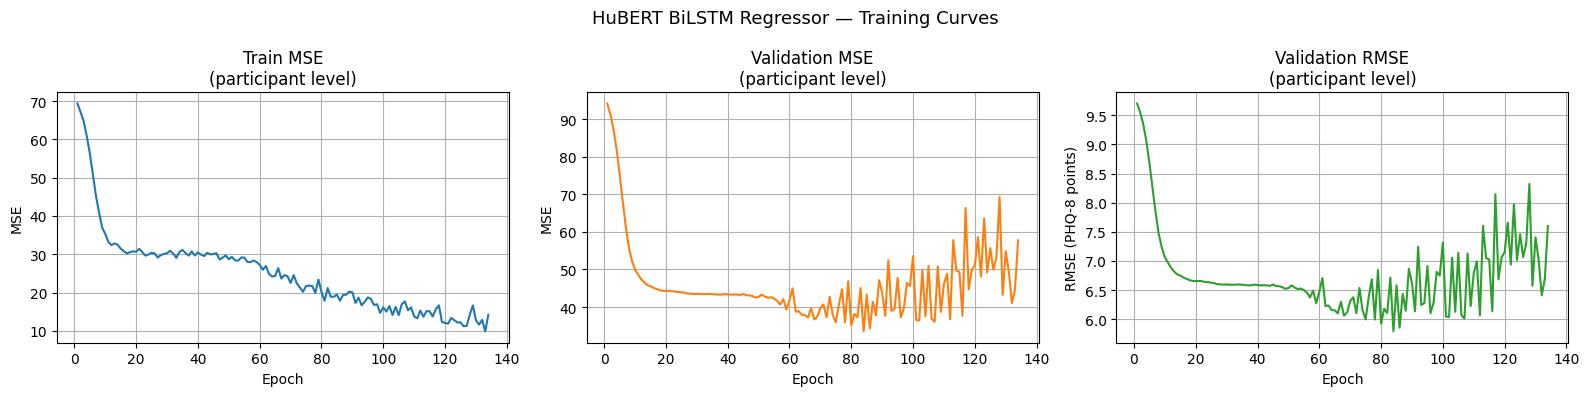

In [9]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_ran, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(participant level)")
axes[0].grid(True)

axes[1].plot(epochs_ran, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs_ran, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.suptitle("HuBERT BiLSTM Regressor \u2014 Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.

In [10]:
best_ckpt = torch.load(
    SAVE_DIR / "HuBERT_biLSTM_best.pth",
    map_location=DEVICE,
    weights_only=True,
)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

_, _, test_df = evaluate("test")

all_preds  = test_df["pred"].values
all_labels = test_df["label"].values

test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print(f"  Participants evaluated: {len(test_df)}")
print("\n\u2500\u2500 Test-set results (participant level) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 84  (val MSE 33.5528)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 45.6738
  RMSE      : 6.7582  PHQ-8 points
  MAE       : 5.4587  PHQ-8 points
  Pearson r : 0.1330


## 10. Prediction Distribution

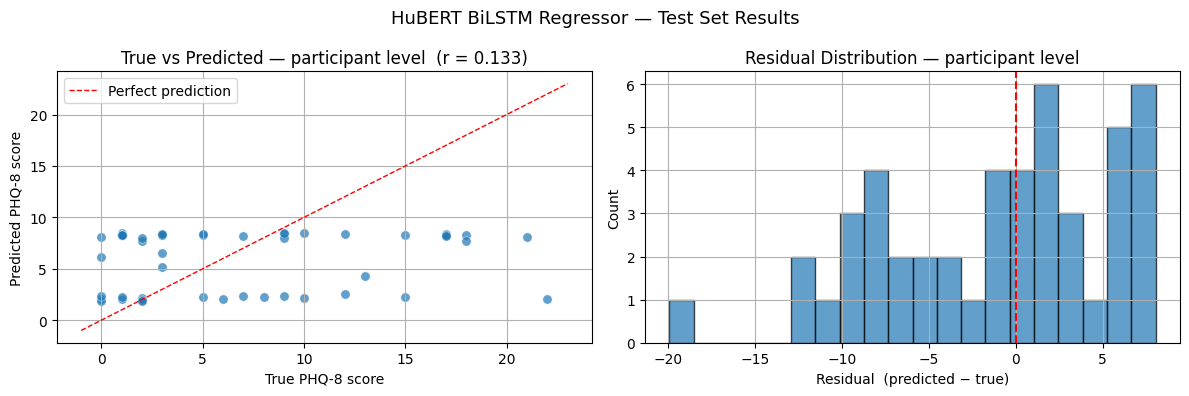

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(all_labels, all_preds, alpha=0.7, s=45,
                edgecolors="white", linewidths=0.4)
lo = min(all_labels.min(), all_preds.min()) - 1
hi = max(all_labels.max(), all_preds.max()) + 1
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted \u2014 participant level  (r = {test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual  (predicted \u2212 true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution \u2014 participant level")
axes[1].grid(True)

plt.suptitle("HuBERT BiLSTM Regressor \u2014 Test Set Results", fontsize=13)
plt.tight_layout()
plt.show()